In [1]:
import pandas as pd

# load data
df_ip = pd.concat(
    [
        pd.read_csv("../tmp/item_properties_part1.csv"),
        pd.read_csv("../tmp/item_properties_part2.csv"),
    ],
    ignore_index=True,
)

In [2]:
# formato
print(f"formato {df_ip.shape}")
print(f"linhas {df_ip.shape[0]} | colunas {df_ip.shape[1]}")
print()

# head
print("head")
print(df_ip.head())
print()

# tail
print("tail")
print(df_ip.tail())
print()

# types
print("types")
print(df_ip.dtypes)
print()

# describe df_ev
df_ip.describe()

formato (20275902, 4)
linhas 20275902 | colunas 4

head
       timestamp  itemid    property                            value
0  1435460400000  460429  categoryid                             1338
1  1441508400000  206783         888          1116713 960601 n277.200
2  1439089200000  395014         400  n552.000 639502 n720.000 424566
3  1431226800000   59481         790                       n15360.000
4  1431831600000  156781         917                           828513

tail
              timestamp  itemid property                             value
20275897  1433646000000  236931      929                           n12.000
20275898  1440903600000  455746        6                     150169 639134
20275899  1439694000000  347565      686                            610834
20275900  1433646000000  287231      867                            769062
20275901  1442113200000  275768      888  888666 n10800.000 746840 1318567

types
timestamp    int64
itemid       int64
property       str
valu

,timestamp,itemid
count,2.027590e+07,2.027590e+07
mean,1.435157e+12,2.333904e+05
std,3.327798e+09,1.348452e+05
min,1.431227e+12,0.000000e+00
25%,1.432436e+12,1.165160e+05
50%,1.433646e+12,2.334830e+05
75%,1.437880e+12,3.503040e+05
max,1.442113e+12,4.668660e+05


In [3]:
# Separar colunas por tipo
colunas_numericas = df_ip.select_dtypes(
    exclude=["object", "category", "string", "datetime64"]
).columns.tolist()
colunas_categoricas = df_ip.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()
colunas_data = df_ip.select_dtypes(include=["datetime64"]).columns.tolist()


print(f"Numéricas ({len(colunas_numericas)}):", colunas_numericas)
print(f"Categóricas ({len(colunas_categoricas)}):", colunas_categoricas)
print(f"Datas ({len(colunas_data)}):", colunas_data)

Numéricas (2): ['timestamp', 'itemid']
Categóricas (2): ['property', 'value']
Datas (0): []


In [4]:
print("Quantidade de valor nulos por coluna")
print(df_ip.isnull().sum())
print()

print("Porcentagem de nulos")
print((df_ip.isnull().sum() / len(df_ip) * 100).round(2))
print()

print("Total duplicadas")
print(df_ip.duplicated().sum())
print()

Quantidade de valor nulos por coluna
timestamp    0
itemid       0
property     0
value        0
dtype: int64

Porcentagem de nulos
timestamp    0.0
itemid       0.0
property     0.0
value        0.0
dtype: float64

Total duplicadas
0



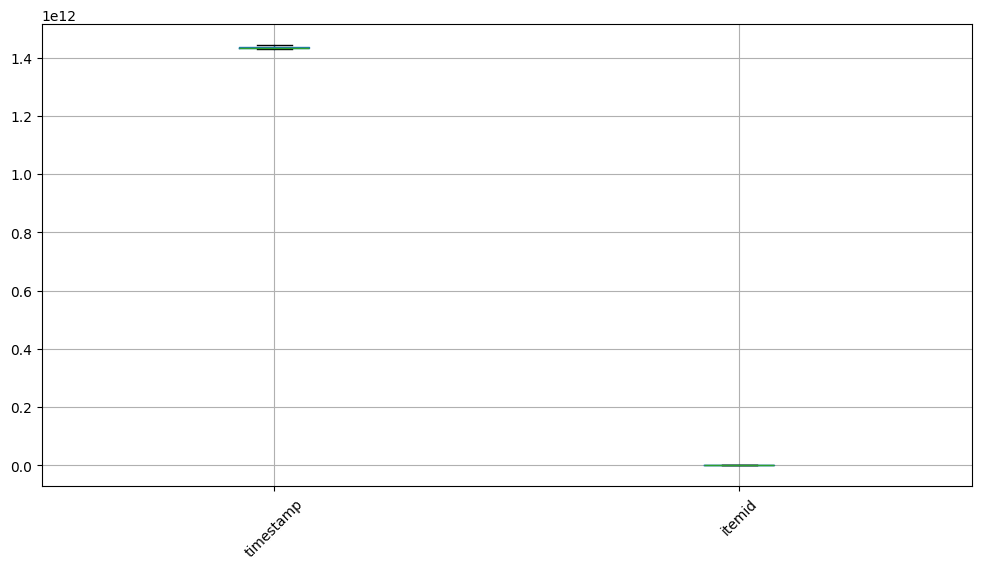

timestamp: 0 outliers
itemid: 0 outliers


In [5]:
import matplotlib.pyplot as plt

# Visualização rápida
df_ip[colunas_numericas].boxplot(figsize=(12, 6))
plt.xticks(rotation=45)
plt.show()

# Método IQR
for col in colunas_numericas:
    Q1 = df_ip[col].quantile(0.25)
    Q3 = df_ip[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df_ip[col] < Q1 - 1.5 * IQR) | (df_ip[col] > Q3 + 1.5 * IQR)).sum()
    print(f"{col}: {outliers} outliers")

In [6]:
print("Valores únicos e frequência")
# Ver valores únicos e frequência
for col in colunas_categoricas:
    print(f"\n{col}: {df_ip[col].nunique()} valores únicos")
    print(df_ip[col].value_counts().head(10))

Valores únicos e frequência

property: 1104 valores únicos
property
888           3000398
790           1790516
available     1503639
categoryid     788214
6              631471
283            597419
776            574220
678            481966
364            476486
202            448938
Name: count, dtype: int64

value: 1966868 valores únicos
value
769062                                 1537247
0                                       863246
1                                       641420
679677                                  417054
519769                                  417053
1285872                                 417053
1116693                                 157243
1297729 n156.000 606827                 120136
664227                                  118653
664227 1305534 664227 463202 664227      96245
Name: count, dtype: int64


## Quantidades
- Views em grandes quantidades 2664312
- Add to cart em segundo lugar 69332
- Transações em terceiro 22457

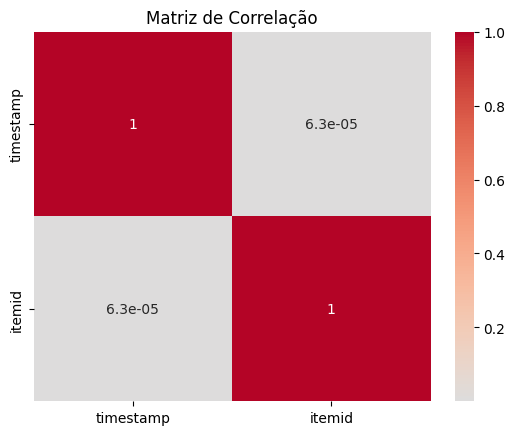

In [7]:
# Matriz de correlação
correlacao = df_ip[colunas_numericas].corr()

import seaborn as sns

# Visualizar
sns.heatmap(correlacao, annot=True, cmap="coolwarm", center=0)
plt.title("Matriz de Correlação")
plt.show()

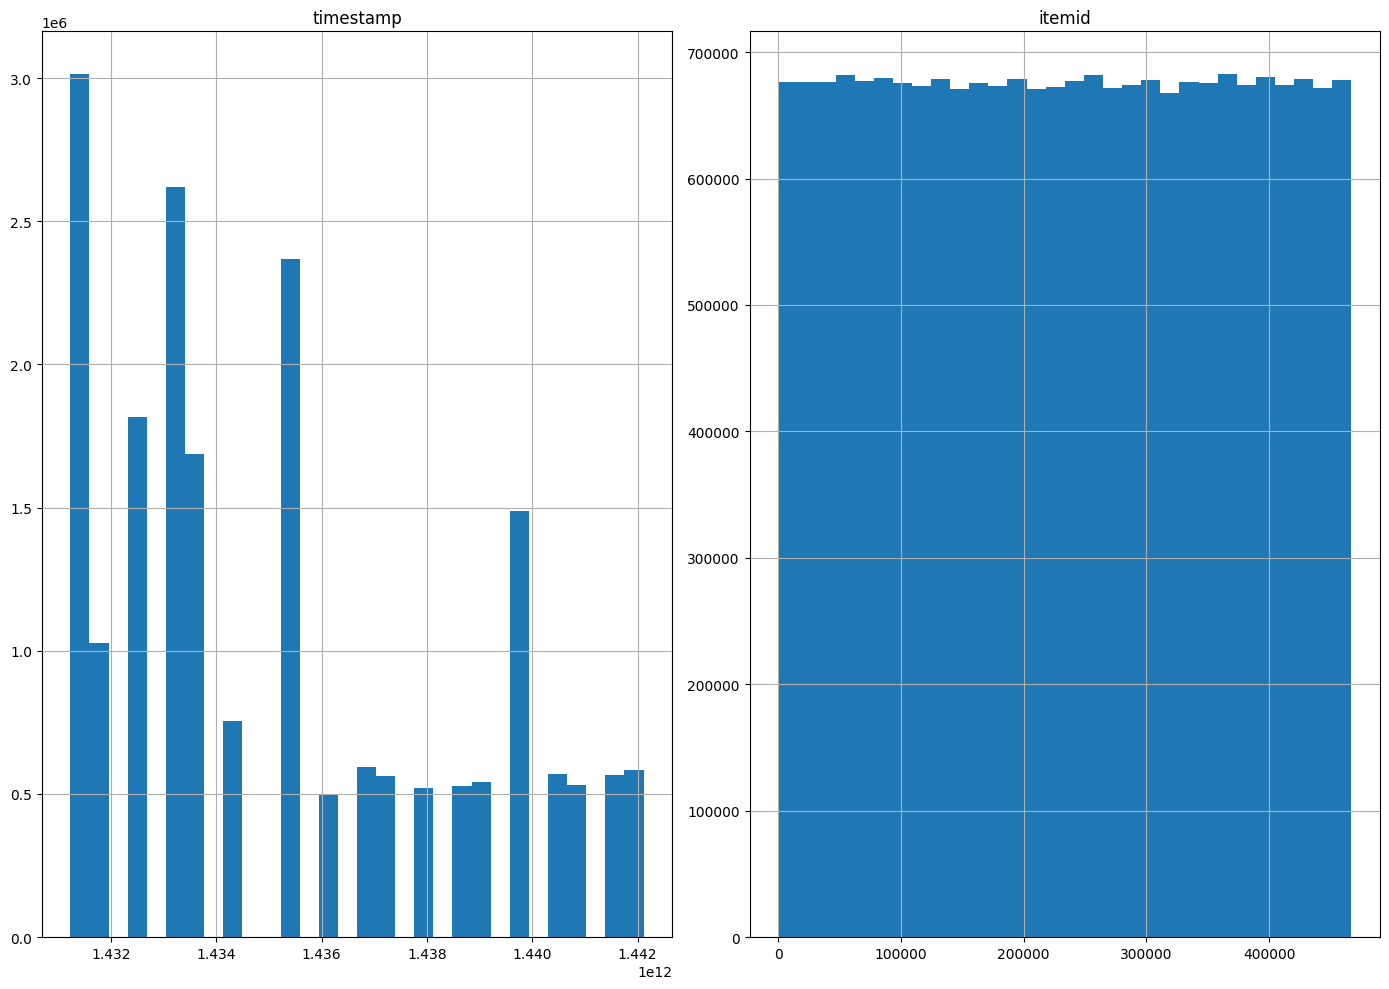

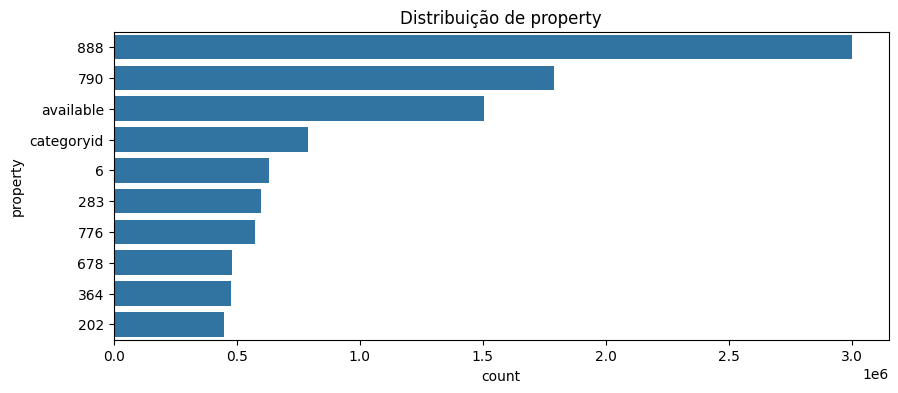

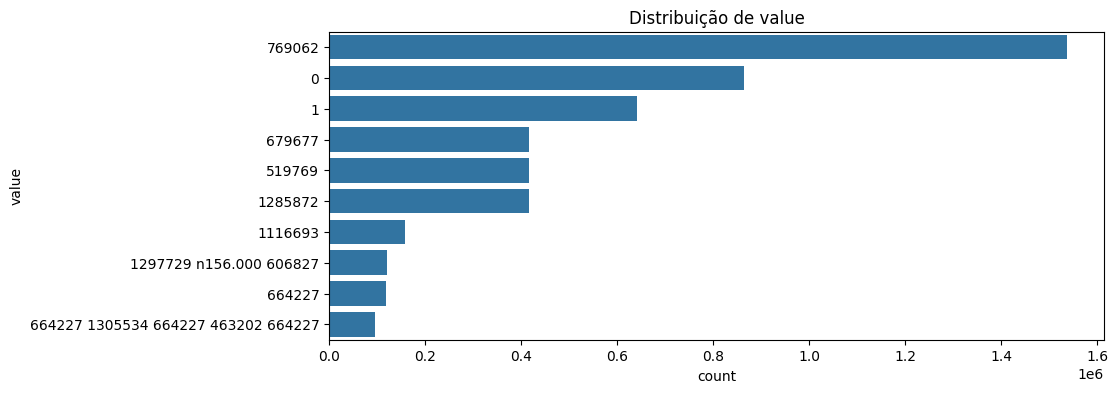

In [8]:
# Histograma para todas as numéricas
df_ip[colunas_numericas].hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

# Countplot para categóricas principais
for col in colunas_categoricas[:5]:  # top 5
    plt.figure(figsize=(10, 4))
    sns.countplot(y=col, data=df_ip, order=df_ip[col].value_counts().index[:10])
    plt.title(f"Distribuição de {col}")
    plt.show()